In [1]:
import kwant
import numpy as np


In [1]:
#参数
dela = 0.3
t = 1
af =0
a = 1
U = 0.4
mz = 1
mu = 0.5
hc=0#100
h =hc * np.sqrt(mu**2 + dela**2)
#0.5*np.sqrt(h**2 - dela**2)
#L = 11
chaodaojiao = 0
saimanjiao = 0#np.pi / 4

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.eye(2, dtype=complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy
Delta_L=dela * np.exp(1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_center_block=(U-mu+2*t)*s0+mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    
H_center_right_to_left_hop=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])
H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy
Delta_R=dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T
H_l= H_L_onsite
T_l= H_L_right_to_left_hop
H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T
T_LD=H_center_to_L
T_RD= H_R_to_center
N=10
q=2
#E=0


NameError: name 'np' is not defined

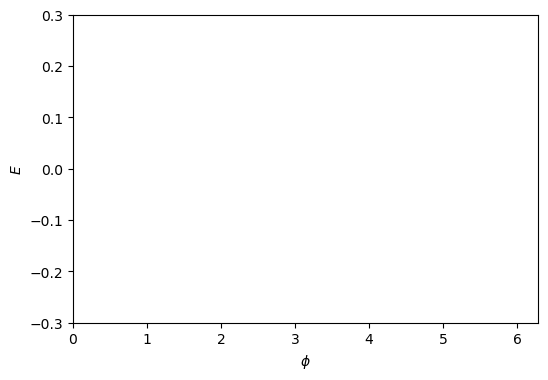

In [4]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

lat = kwant.lattice.chain(norbs=4)
syst = kwant.Builder()

for i in range(N):
    syst[lat(i)] = H_center
    if i > 0:
        syst[lat(i), lat(i-1)] = H_center_right_to_left_hop
def H_L_onsite(phi):
    Delta_L = dela * np.exp(1j * phi / 2) * 1j * sy
    HL = -(mu - 2*t) * s0
    return np.block([
        [ HL,            Delta_L ],
        [ Delta_L.conj().T, -HL.conj() ]
    ])

def onsite_L(site, phi):
    return H_L_onsite(phi)


lead_L = kwant.Builder(kwant.TranslationalSymmetry((-1,)))
lead_L[lat(0)] = onsite_L
lead_L[lat(0), lat(-1)] = H_L_right_to_left_hop
def H_R_onsite(phi):
    Delta_R = dela * np.exp(-1j * phi / 2) * 1j * sy
    HR = -(mu - 2*t) * s0
    return np.block([
        [ HR,            Delta_R ],
        [ Delta_R.conj().T, -HR.conj() ]
    ])

def onsite_R(site, phi):
    return H_R_onsite(phi)

lead_R = kwant.Builder(kwant.TranslationalSymmetry((1,)))
lead_R[lat(0)] = onsite_R
lead_R[lat(0), lat(1)] = H_R_right_to_left_hop
syst.attach_lead(lead_L)
syst.attach_lead(lead_R)
syst = syst.finalized()
import numpy.linalg as la

def abs_energies(phi, tol=1e-3):
    Es = np.linspace(-dela, dela, 600)
    abs_E = []

    for E in Es:
        try:
            gf = greens_function(syst, E, params=dict(phi=phi))
            M = gf.inverse      # = E - H_eff(E)

            # 关键：最小奇异值
            svals = la.svd(M, compute_uv=False)
            if np.min(svals) < tol:
                abs_E.append(E)

        except:
            pass

    return np.unique(np.round(abs_E, 4))


phis = np.linspace(0, 2*np.pi, 10)

phi_list = []
E_list = []

for phi in phis:
    Es = abs_energies(phi)
    for E in Es:
        phi_list.append(phi)
        E_list.append(E)

plt.figure(figsize=(6,4))
plt.scatter(phi_list, E_list, s=6, c='k')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$E$')
plt.ylim(-dela, dela)
plt.xlim(0, 2*np.pi)
plt.show()
